In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
soil_full_microbiome = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Generated_data/soil_full_microbiome.csv"
)
plant_full_microbiome = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Generated_data/plant_full_microbiome.csv"
)

In [3]:
len(
    plant_full_microbiome["Species"]
    .loc[plant_full_microbiome["Species"].isin(soil_full_microbiome["Species"])]
    .unique()
)

253

In [4]:
print(len(soil_full_microbiome["Species"].unique()))
print(len(plant_full_microbiome["Species"].unique()))

979
279


In [5]:
import importlib.util

(
    soil_full_microbiome.columns.tolist(),
    soil_full_microbiome.head(),
    importlib.util.find_spec("plotly") is not None,
)

(['Sample',
  'sample.type',
  'timepoint',
  'date',
  'time',
  'platename',
  'daysincestart',
  'Kingdom',
  'Phylum',
  'Class',
  'Order',
  'Family',
  'Genus',
  'Species',
  'AbundR100',
  'sampID',
  'Date and Time'],
    Sample sample.type timepoint     date  time platename  daysincestart  \
 0  LIC009        soil       t01  11/1/23  8:00    LIC_01              0   
 1  LIC009        soil       t01  11/1/23  8:00    LIC_01              0   
 2  LIC009        soil       t01  11/1/23  8:00    LIC_01              0   
 3  LIC009        soil       t01  11/1/23  8:00    LIC_01              0   
 4  LIC009        soil       t01  11/1/23  8:00    LIC_01              0   
 
        Kingdom             Phylum                Class                Order  \
 0  d__Bacteria     Pseudomonadota  Gammaproteobacteria      Burkholderiales   
 1  d__Bacteria     Pseudomonadota  Gammaproteobacteria      Burkholderiales   
 2  d__Bacteria     Actinomycetota      Thermoleophilia  Solirubrobacteral

In [6]:
plant_full_microbiome

,Sample,sample.type,timepoint,date,time,platename,daysincestart,plantID,Kingdom,Phylum,Class,Order,Family,Genus,Species,AbundR100,sampID,Experiment Type
0,LIC522,plant,c1_t11,2/11/24,12:00,LICCIRC_02,102,LIC522,d__Bacteria,Pseudomonadota,Gammaproteobacteria,Pseudomonadales_A_650611,Pseudomonadaceae,Pseudomonas_E_647464,Pseudomonas_E_647464 viridiflava,79.1,LIC522,Circadian Experiment 1
1,LIC063,plant,t06,11/28/23,8:00,LIC_01,27,LIC063,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Sphingomonadales,Sphingomonadaceae_486827,Sphingomonas_L_486704,Sphingomonas_L_486704 sp000786205,66.1,LIC063,Long Term
2,LIC159,plant,t14,1/23/24,8:00,LIC_02,83,LIC159,d__Bacteria,Cyanobacteriota,Cyanobacteriia,Cyanobacteriales,Coleofasciculaceae,Caldora,Caldora sp010672925,60.5,LIC159,Long Term
3,LIC452,plant,c1_t06,2/10/24,16:00,LICCIRC_01,101,LIC452,d__Bacteria,Pseudomonadota,Gammaproteobacteria,Burkholderiales,Burkholderiaceae_A_595421,Massilia_574544,Massilia atriviolacea,59.8,LIC452,Circadian Experiment 1
4,LIC306,plant,t26,3/8/24,8:00,LIC_04,128,LIC306,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Sphingomonadales,Sphingomonadaceae_486827,Sphingomonas_L_486704,Sphingomonas_L_486704 sp000786205,57.2,LIC306,Long Term
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12281,LIC122,plant,t11,12/15/23,8:00,LIC_02,44,LIC122,d__Bacteria,Actinomycetota,Actinomycetes,Propionibacteriales,Nocardioidaceae,Nocardioides_A_392796,Nocardioides_A_392796 hankookensis,0.5,LIC122,Long Term
12282,LIC028,plant,t03,11/14/23,8:00,LIC_01,13,LIC028,d__Bacteria,Actinomycetota,Actinomycetes,Mycobacteriales,Geodermatophilaceae,Modestobacter,Modestobacter muralis,0.5,LIC028,Long Term
12283,LIC631,plant,c2_t05,3/2/24,12:00,LICCIRC_03,122,LIC631,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Caulobacterales,Caulobacteraceae,Brevundimonas,Brevundimonas subvibrioides,0.5,LIC631,Circadian Experiment 2
12284,LIC629,plant,c2_t05,3/2/24,12:00,LICCIRC_03,122,LIC629,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Rhizobiales_505101,Rhizobiaceae,Agrobacterium,Agrobacterium larrymoorei,0.5,LIC629,Circadian Experiment 2


## Rare-Species AUROC Analysis

This analysis defines rare species using the full plant microbiome dataset, where a species is rare if it is present in fewer than 10% of all plant samples.

For each timepoint, it evaluates two heuristics against that ground truth on the species observed in at least one sample within that timepoint:

1. Species present in exactly one sample in that timepoint, ranked by lower `AbundR100`.
2. Species with median `AbundR100 < 1` within that timepoint, with lower median abundance ranked higher among species that pass the threshold.

Per timepoint, the notebook reports how many species each method classifies correctly and incorrectly. AUROC is then calculated once across all pooled timepoint-species evaluations for each method.

Rare species are defined as species present in fewer than 10% of all samples: <37.2 of 372 samples total.
Number of rare species in the full dataset: 214


,method,auroc,n_timepoint_species_evaluations,n_true_rare_labels
0,Singleton in one sample + lower abundance rank...,0.792,3791,1212
1,Median AbundR100 < 1 + lower median abundance ...,0.743,3791,1212


,timepoint,method,right,wrong,species_evaluated,true_rare_species,predicted_rare_species
0,c1_t01,Median AbundR100 < 1 + lower median abundance ...,44,43,87,30,73
1,c1_t02,Median AbundR100 < 1 + lower median abundance ...,36,43,79,22,65
2,c1_t03,Median AbundR100 < 1 + lower median abundance ...,26,42,68,13,55
3,c1_t04,Median AbundR100 < 1 + lower median abundance ...,28,41,69,14,55
4,c1_t05,Median AbundR100 < 1 + lower median abundance ...,34,36,70,20,56
...,...,...,...,...,...,...,...
89,t24,Singleton in one sample + lower abundance rank...,55,15,70,12,25
90,t25,Singleton in one sample + lower abundance rank...,70,16,86,26,32
91,t26,Singleton in one sample + lower abundance rank...,55,16,71,17,27
92,t27,Singleton in one sample + lower abundance rank...,64,14,78,25,25


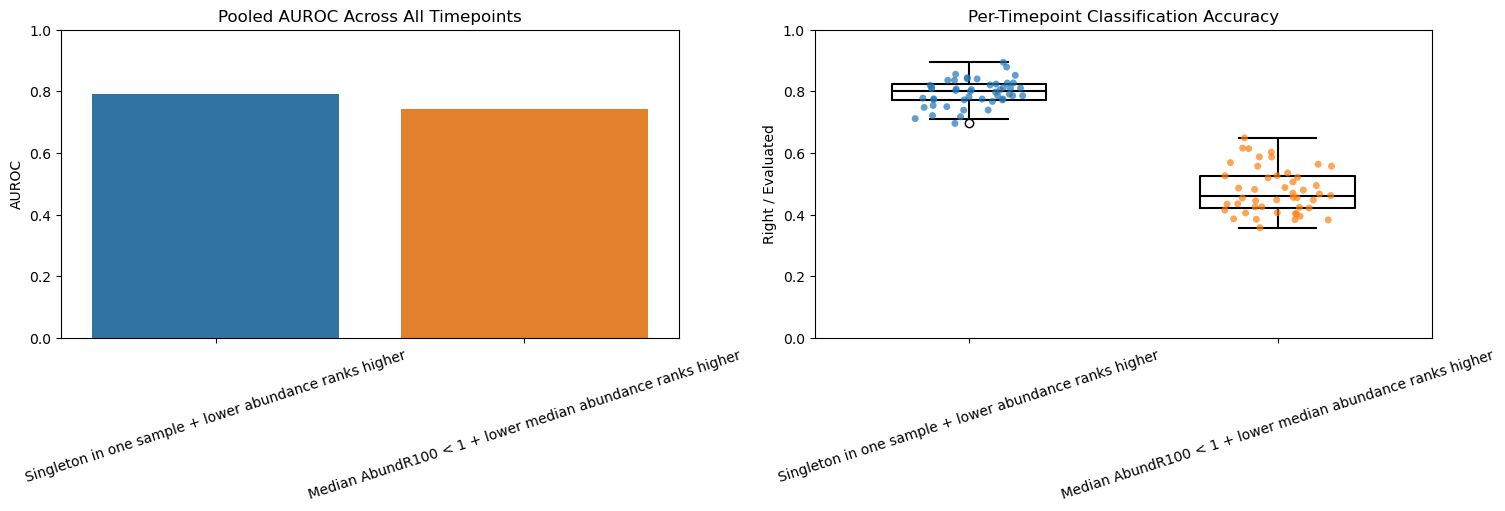

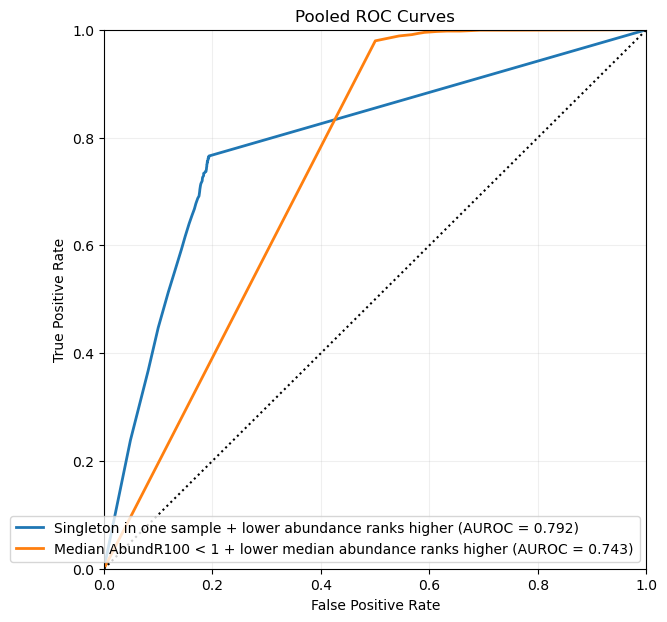

In [7]:
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve

species_sample_abundance = (
    plant_full_microbiome.groupby(["timepoint", "Sample", "Species"], as_index=False)[
        "AbundR100"
    ]
    .sum()
    .rename(columns={"AbundR100": "abundance"})
)

total_samples = species_sample_abundance["Sample"].nunique()
rare_fraction_threshold = 0.10
rare_sample_threshold = total_samples * rare_fraction_threshold

species_ground_truth = (
    species_sample_abundance.groupby("Species")["Sample"]
    .nunique()
    .rename("samples_present_total")
    .to_frame()
    .assign(
        presence_fraction=lambda df: df["samples_present_total"] / total_samples,
        is_rare=lambda df: df["presence_fraction"] < rare_fraction_threshold,
    )
)

evaluation_frames = []

for timepoint, timepoint_df in species_sample_abundance.groupby("timepoint", sort=True):
    species_by_sample = timepoint_df.pivot_table(
        index="Species",
        columns="Sample",
        values="abundance",
        aggfunc="sum",
        fill_value=0,
    )

    evaluation_df = pd.DataFrame(
        {
            "samples_present_timepoint": (species_by_sample > 0).sum(axis=1),
            "min_positive_abundance": species_by_sample.where(
                species_by_sample > 0
            ).min(axis=1),
            "median_abundance": species_by_sample.median(axis=1),
        }
    ).join(species_ground_truth, how="left")

    evaluation_df = evaluation_df[evaluation_df["samples_present_timepoint"] > 0].copy()
    evaluation_df["timepoint"] = timepoint

    evaluation_df["singleton_prediction"] = evaluation_df[
        "samples_present_timepoint"
    ].eq(1)
    evaluation_df["singleton_low_abund_score"] = np.where(
        evaluation_df["singleton_prediction"],
        1 + (1 / (1 + evaluation_df["min_positive_abundance"])),
        0,
    )

    evaluation_df["median_lt1_prediction"] = evaluation_df["median_abundance"] < 1
    evaluation_df["median_lt1_low_abund_score"] = np.where(
        evaluation_df["median_lt1_prediction"],
        1 + (1 / (1 + evaluation_df["median_abundance"])),
        0,
    )

    evaluation_frames.append(evaluation_df.reset_index())

all_evaluations = pd.concat(evaluation_frames, ignore_index=True)

method_definitions = {
    "Singleton in one sample + lower abundance ranks higher": {
        "prediction_column": "singleton_prediction",
        "score_column": "singleton_low_abund_score",
    },
    "Median AbundR100 < 1 + lower median abundance ranks higher": {
        "prediction_column": "median_lt1_prediction",
        "score_column": "median_lt1_low_abund_score",
    },
}

pooled_auc_records = []
pooled_roc_curves = {}
timepoint_accuracy_records = []

for method_name, method_columns in method_definitions.items():
    prediction_column = method_columns["prediction_column"]
    score_column = method_columns["score_column"]

    fpr, tpr, _ = roc_curve(
        all_evaluations["is_rare"].astype(int),
        all_evaluations[score_column],
    )
    auc_value = roc_auc_score(
        all_evaluations["is_rare"].astype(int),
        all_evaluations[score_column],
    )

    pooled_auc_records.append(
        {
            "method": method_name,
            "auroc": auc_value,
            "n_timepoint_species_evaluations": len(all_evaluations),
            "n_true_rare_labels": int(all_evaluations["is_rare"].sum()),
        }
    )
    pooled_roc_curves[method_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auroc": auc_value,
    }

    per_timepoint = (
        all_evaluations.assign(
            correct=lambda df: df[prediction_column].eq(df["is_rare"]),
            wrong=lambda df: df[prediction_column].ne(df["is_rare"]),
        )
        .groupby("timepoint", as_index=False)
        .agg(
            right=("correct", "sum"),
            wrong=("wrong", "sum"),
            species_evaluated=("Species", "size"),
            true_rare_species=("is_rare", "sum"),
            predicted_rare_species=(prediction_column, "sum"),
        )
    )
    per_timepoint["method"] = method_name
    timepoint_accuracy_records.append(per_timepoint)

pooled_auc_results = pd.DataFrame(pooled_auc_records).sort_values(
    "auroc", ascending=False
)
timepoint_accuracy = pd.concat(timepoint_accuracy_records, ignore_index=True)
timepoint_accuracy = timepoint_accuracy[
    [
        "timepoint",
        "method",
        "right",
        "wrong",
        "species_evaluated",
        "true_rare_species",
        "predicted_rare_species",
    ]
].sort_values(["method", "timepoint"])
timepoint_accuracy = timepoint_accuracy.reset_index(drop=True)

print(
    f"Rare species are defined as species present in fewer than 10% of all samples: "
    f"<{rare_sample_threshold:.1f} of {total_samples} samples total."
)
print(
    f"Number of rare species in the full dataset: {int(species_ground_truth['is_rare'].sum())}"
)

display(pooled_auc_results.round(3))
display(timepoint_accuracy)

plot_df = pooled_auc_results.copy()
plot_df["method"] = pd.Categorical(
    plot_df["method"],
    categories=plot_df.sort_values("auroc", ascending=False)["method"].tolist(),
    ordered=True,
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

sns.barplot(
    data=plot_df,
    x="method",
    y="auroc",
    ax=axes[0],
    hue="method",
    dodge=False,
    legend=False,
)
axes[0].set_title("Pooled AUROC Across All Timepoints")
axes[0].set_xlabel("")
axes[0].set_ylabel("AUROC")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=18)

accuracy_plot_df = timepoint_accuracy.copy()
accuracy_plot_df["accuracy"] = (
    accuracy_plot_df["right"] / accuracy_plot_df["species_evaluated"]
)
accuracy_plot_df["method"] = pd.Categorical(
    accuracy_plot_df["method"],
    categories=plot_df["method"].tolist(),
    ordered=True,
)

sns.boxplot(
    data=accuracy_plot_df,
    x="method",
    y="accuracy",
    ax=axes[1],
    fill=False,
    width=0.5,
    color="black",
)
sns.stripplot(
    data=accuracy_plot_df,
    x="method",
    y="accuracy",
    ax=axes[1],
    hue="method",
    dodge=False,
    jitter=0.18,
    alpha=0.7,
    size=5,
    legend=False,
)
axes[1].set_title("Per-Timepoint Classification Accuracy")
axes[1].set_xlabel("")
axes[1].set_ylabel("Right / Evaluated")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=18)

plt.show()

roc_fig, roc_ax = plt.subplots(figsize=(7, 7))

for method_name in plot_df.sort_values("auroc", ascending=False)["method"]:
    roc_ax.plot(
        pooled_roc_curves[method_name]["fpr"],
        pooled_roc_curves[method_name]["tpr"],
        linewidth=2,
        label=f"{method_name} (AUROC = {pooled_roc_curves[method_name]['auroc']:.3f})",
    )

roc_ax.plot([0, 1], [0, 1], linestyle=":", color="black", linewidth=1.5)
roc_ax.set_title("Pooled ROC Curves")
roc_ax.set_xlabel("False Positive Rate")
roc_ax.set_ylabel("True Positive Rate")
roc_ax.set_xlim(0, 1)
roc_ax.set_ylim(0, 1)
roc_ax.legend(loc="lower right")
roc_ax.grid(alpha=0.2)

plt.show()

## Soil-To-Plant Rare Species Flow

This section applies the same rare-species rule separately to the soil microbiome and the plant microbiome: a species is rare if it is present in fewer than 10% of samples within that dataset.

It also uses Fisher's exact test to assess enrichment of soil rare and soil common species in each of the three plant outcomes, using all soil species as the background.

The first Sankey diagram tracks species found in soil into three plant outcomes: plant rare, plant common, or not present in plants. Species found in plants but not in soil are excluded.

The second Sankey diagram restricts to species shared by soil and plants, removing the `Not Present in Plants` category.

In [8]:
import numpy as np
import plotly.graph_objects as go
from pathlib import Path
from scipy.stats import fisher_exact


def classify_species_by_presence(microbiome_df):
    species_sample_presence = (
        microbiome_df.groupby(["Sample", "Species"], as_index=False)["AbundR100"]
        .sum()
        .rename(columns={"AbundR100": "abundance"})
    )
    total_samples = species_sample_presence["Sample"].nunique()
    rare_fraction_threshold = 0.10

    return (
        species_sample_presence.groupby("Species")["Sample"]
        .nunique()
        .rename("samples_present")
        .to_frame()
        .assign(
            total_samples=total_samples,
            presence_fraction=lambda df: df["samples_present"] / df["total_samples"],
            classification=lambda df: np.where(
                df["presence_fraction"] < rare_fraction_threshold,
                "Rare",
                "Common",
            ),
        )
    )


def make_sankey(
    flow_df,
    node_labels,
    title_text,
    width=950,
    height=550,
    show_node_counts=False,
):
    node_index = {label: index for index, label in enumerate(node_labels)}
    display_labels = node_labels

    if show_node_counts:
        source_counts = flow_df.groupby("source")["species_count"].sum()
        target_counts = flow_df.groupby("target")["species_count"].sum()
        node_totals = pd.concat([source_counts, target_counts], axis=1).max(axis=1)
        node_totals = node_totals.reindex(node_labels, fill_value=0).astype(int)
        display_labels = [f"{label} (n={node_totals[label]})" for label in node_labels]

    figure = go.Figure(
        data=[
            go.Sankey(
                arrangement="snap",
                node=dict(
                    label=display_labels,
                    pad=18,
                    thickness=22,
                    color=["#7a9e7e", "#30475e", "#d97d54", "#5c8d89", "#b0b7c3"][
                        : len(node_labels)
                    ],
                ),
                link=dict(
                    source=flow_df["source"].map(node_index).tolist(),
                    target=flow_df["target"].map(node_index).tolist(),
                    value=flow_df["species_count"].tolist(),
                    label=(
                        flow_df["soil_classification"]
                        + " -> "
                        + flow_df["plant_classification"]
                        + " | species: "
                        + flow_df["species_count"].astype(str)
                    ).tolist(),
                ),
            )
        ]
    )
    figure.update_layout(
        title_text=title_text,
        font_size=12,
        width=width,
        height=height,
    )
    return figure


soil_species_classification = classify_species_by_presence(soil_full_microbiome)
plant_species_classification = classify_species_by_presence(plant_full_microbiome)

soil_to_plant_flow = (
    soil_species_classification[["classification"]]
    .rename(columns={"classification": "soil_classification"})
    .join(
        plant_species_classification[["classification"]].rename(
            columns={"classification": "plant_classification"}
        ),
        how="left",
    )
    .assign(
        plant_classification=lambda df: df["plant_classification"].fillna(
            "Not Present in Plants"
        )
    )
    .reset_index(names="Species")
)

flow_counts = (
    soil_to_plant_flow.groupby(
        ["soil_classification", "plant_classification"], as_index=False
    )
    .agg(species_count=("Species", "nunique"))
    .sort_values(["soil_classification", "plant_classification"])
)

display(
    flow_counts.pivot(
        index="soil_classification",
        columns="plant_classification",
        values="species_count",
    )
    .fillna(0)
    .astype(int)
)

background_total = len(soil_to_plant_flow)
soil_class_totals = soil_to_plant_flow["soil_classification"].value_counts()
plant_class_totals = soil_to_plant_flow["plant_classification"].value_counts()

enrichment_records = []

for soil_class in ["Common", "Rare"]:
    for plant_class in ["Common", "Rare", "Not Present in Plants"]:
        overlap = int(
            flow_counts.loc[
                flow_counts["soil_classification"].eq(soil_class)
                & flow_counts["plant_classification"].eq(plant_class),
                "species_count",
            ].sum()
        )
        soil_not_plant = int(soil_class_totals[soil_class] - overlap)
        plant_not_soil = int(plant_class_totals[plant_class] - overlap)
        neither = int(background_total - overlap - soil_not_plant - plant_not_soil)

        odds_ratio, p_value = fisher_exact(
            [[overlap, soil_not_plant], [plant_not_soil, neither]],
            alternative="greater",
        )

        enrichment_records.append(
            {
                "soil_classification": soil_class,
                "plant_classification": plant_class,
                "overlap_species": overlap,
                "soil_class_total": int(soil_class_totals[soil_class]),
                "plant_class_total": int(plant_class_totals[plant_class]),
                "background_total_soil_species": background_total,
                "odds_ratio": odds_ratio,
                "p_value_greater": p_value,
            }
        )

enrichment_results = (
    pd.DataFrame(enrichment_records)
    .sort_values(["soil_classification", "plant_classification"])
    .reset_index(drop=True)
)
enrichment_display = enrichment_results.copy()
enrichment_display["odds_ratio"] = enrichment_display["odds_ratio"].round(3)

display(
    enrichment_display[
        [
            "soil_classification",
            "plant_classification",
            "overlap_species",
            "soil_class_total",
            "plant_class_total",
            "background_total_soil_species",
            "odds_ratio",
            "p_value_greater",
        ]
    ]
)

all_species_flow = flow_counts.copy()
all_species_flow["source"] = all_species_flow["soil_classification"].map(
    {"Rare": "Soil Rare", "Common": "Soil Common"}
)
all_species_flow["target"] = all_species_flow["plant_classification"].map(
    {
        "Rare": "Plant Rare",
        "Common": "Plant Common",
        "Not Present in Plants": "Not Present in Plants",
    }
)

all_species_node_labels = [
    "Soil Rare",
    "Soil Common",
    "Plant Rare",
    "Plant Common",
    "Not Present in Plants",
]

all_species_fig = make_sankey(
    all_species_flow,
    all_species_node_labels,
    "Flow of Soil Species Into Plant Rare, Common, or Absent Classes",
    width=1100,
    show_node_counts=True,
)
output_path = Path(
    "/Users/michael/Git/Outdoor_microbiome/Local_analysis/Making_figures_for_paper/Fig2/Soil_species_flow.pdf"
)
output_path.parent.mkdir(parents=True, exist_ok=True)
all_species_fig.write_image(output_path)
print(f"Saved first Sankey figure to {output_path}")
all_species_fig.show()

shared_species_flow = flow_counts.loc[
    flow_counts["plant_classification"].ne("Not Present in Plants")
]
shared_species_flow = shared_species_flow.copy()
shared_species_flow["source"] = shared_species_flow["soil_classification"].map(
    {"Rare": "Soil Rare", "Common": "Soil Common"}
)
shared_species_flow["target"] = shared_species_flow["plant_classification"].map(
    {
        "Rare": "Plant Rare",
        "Common": "Plant Common",
    }
)

display(
    shared_species_flow.pivot(
        index="soil_classification",
        columns="plant_classification",
        values="species_count",
    )
    .fillna(0)
    .astype(int)
)

shared_species_node_labels = [
    "Soil Rare",
    "Soil Common",
    "Plant Rare",
    "Plant Common",
]

shared_species_fig = make_sankey(
    shared_species_flow,
    shared_species_node_labels,
    "Flow of Shared Soil Species Into Plant Rare or Common Classes",
)
shared_species_fig.show()

plant_classification,Common,Not Present in Plants,Rare
soil_classification,,,
Common,62,181,109
Rare,3,545,79


,soil_classification,plant_classification,overlap_species,soil_class_total,plant_class_total,background_total_soil_species,odds_ratio,p_value_greater
0,Common,Common,62,352,65,979,44.469,9.678682e-26
1,Common,Not Present in Plants,181,352,726,979,0.159,1.000000e+00
2,Common,Rare,109,352,188,979,3.112,5.541101e-12
3,Rare,Common,3,627,65,979,0.022,1.000000e+00
4,Rare,Not Present in Plants,545,627,726,979,6.279,3.053093e-33
5,Rare,Rare,79,627,188,979,0.321,1.000000e+00


Saved first Sankey figure to /Users/michael/Git/Outdoor_microbiome/Local_analysis/Making_figures_for_paper/Fig2/Soil_species_flow.pdf


plant_classification,Common,Rare
soil_classification,,
Common,62,109
Rare,3,79
